## Package import
We first need to import the necessary packages to run this example

In [2]:
import brillouinanalyzer as bp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

## Load and Process Brillouin Data
In the following cell, we:
1. Define the project path where our Brillouin data is stored
2. Load the spectral image data using the brillouinanalyzer utility function
3. Calculate the frequency scale for the Brillouin spectra by:
    - Setting the mirror spacing to 6 mm
    - Using a scan amplitude of 480 nm 
    - Taking the number of spectral channels from the data
4. Create a SpectralImage object that combines the raw data with the calculated frequency scale

This creates the brillouin_data object which contains both the spectral information and the corresponding frequency axis for further analysis. The frequency scale ranges from approximately -22.5 GHz to +22.5 GHz across 1024 channels.

In [3]:
project_path = r'C:\\Users\\Timm\\Desktop\\Leipzig\\Zygo_2_4'
# Load of the Brillouin spectral data
brillouin_data = bp.utils.load_spectral_image(project_path, 'Brillouin')
# Calculate the Frequency axis of the Brillouin data.
brillouin_frequency_scale = bp.utils.brillouin_spectral_axis(
    mirror_spacing = 6e-3, # [m]
    scan_amplitude = 480e-9, # [m]
    no_of_channels = brillouin_data.shape[-1] # get spectral dimension from data
)

# Generate the Brillouin object
brillouin_data = bp.SpectralImage(brillouin_data, brillouin_frequency_scale)

Processing Spectral data: 100%|██████████| 900/900 [00:00<00:00, 2470.16it/s]


## Data Processing and Analysis Overview

The subsequent code implements a sophisticated analysis pipeline for Brillouin spectroscopy data. Here's what happens step by step:

1. **Preprocessing Pipeline**
    - Creates a processing pipeline with multiple steps:
    - Pixel-wise intensity normalization to account for variations
    - Deconvolution to remove the Instrument Response Function (IRF)
      - Uses an offset of 65 to remove unwanted Rayleigh scattered light
      - Performs 4 iterations for optimal deconvolution

2. **Data Visualization**
    - Displays comparative plots of:
      - Raw Brillouin data (log scale)
      - Processed data after pipeline application (linear scale)
    - Allows visual assessment of the preprocessing effects

3. **Damped Harmonic Oscillator (DHO) Fitting**
    - Applies DHO model with parameters:
      - Single peak detection
      - Initial parameters:
         - Amplitude: 0.005
         - Frequency Shift: 8.5 GHz
         - FWHM: 1 GHz
         - Background: 0
         - Symmetry: 0

4. **Results Visualization**
    - Generates three heatmaps showing spatial distribution of:
      - Peak amplitude
      - Frequency shifts
      - Linewidth measurements
    - Each map includes a colorbar for quantitative interpretation

This analysis provides comprehensive characterization of the Brillouin spectra's key parameters across the sample.

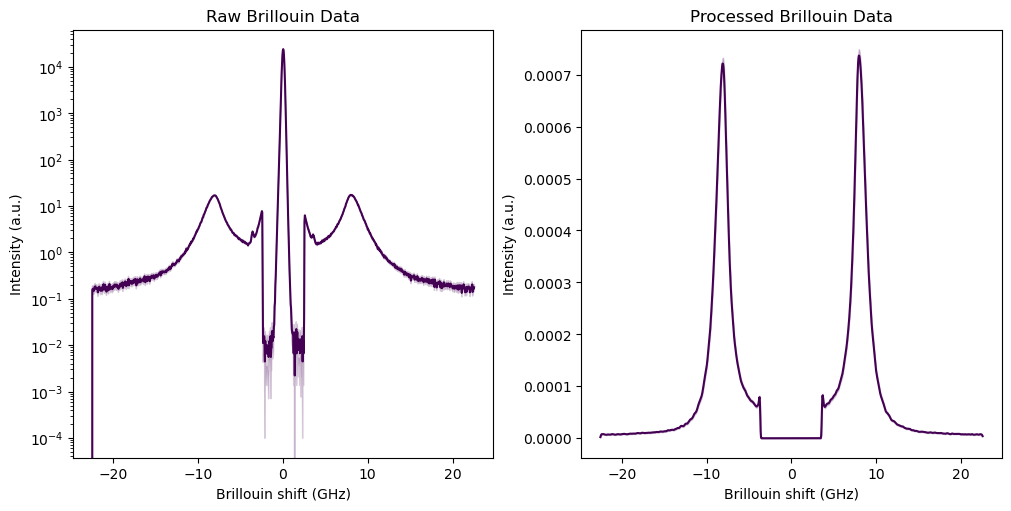

Starting of Multiprocessing can take up to 10 seconds.


Fitting Spectral data: 100%|██████████| 900/900 [00:08<00:00, 105.75it/s]


DHO Amplitude: 0.0019252029290448296 +/- 0.00041407151471188446
DHO Frequency: 8.289765098626622 +/- 0.20577493199980068
DHO Linewidth: 0.8421112495505235 +/- 0.18595796752320531
DHO Background: 8.079262331197931e-06 +/- 5.409976308342435e-06
DHO Symmetry: 0.0006684111761985677 +/- 0.003616191322828652


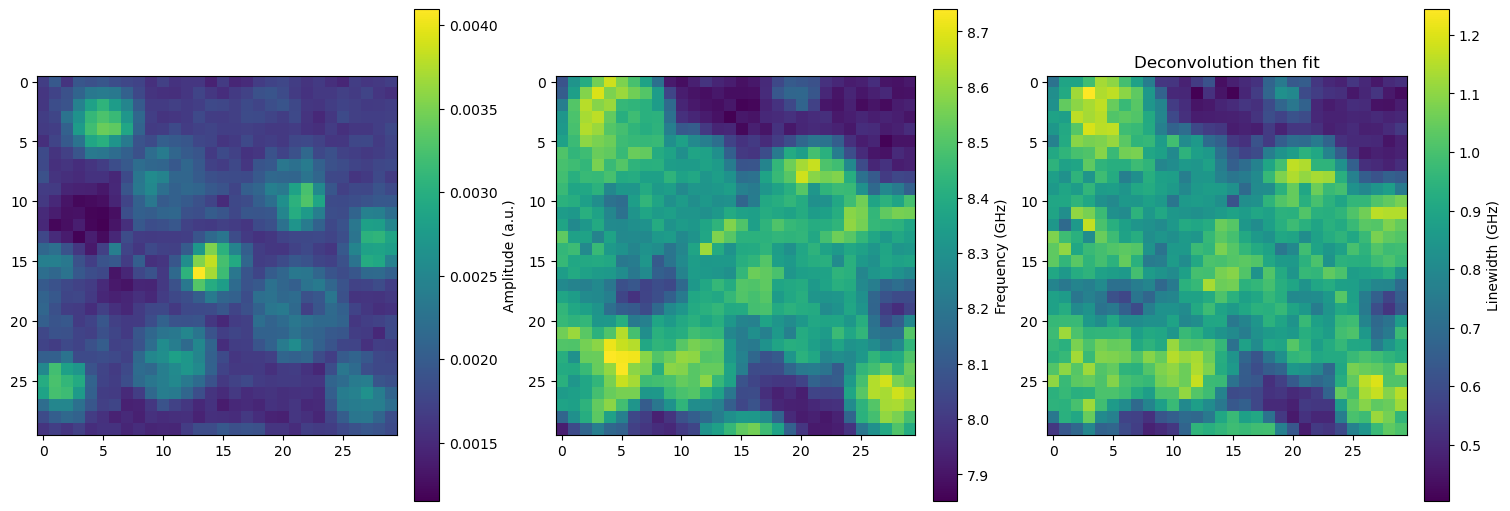

In [4]:
#%%% Basic Analysis
#
# Define the processing pipeline. This gives you an example on what data manipulation/processing is possible
pipeline = bp.preprocessing.Pipeline([
    # # Normalization regarding the spectrometer performance
    bp.preprocessing.normalise.MaxIntensity(pixelwise=True # When pixelwise normalization is wanted
                                            ),

    # # Removal of the Intrument Response Function (IRF) and intensity signal deconvolution
    bp.preprocessing.misc.Deconvoluter_IRF(offset=65, # additional offset from IRF. You can use this parameter to remove unwanted Rayleigh scattered light
                                            iterations = 4, # This is the number of iteration cycles. This is not something that should be changed unintentionally
                                            padding = None # currently not in use
                                            ),

    # # Smooting of the intensity
    # bp.preprocessing.denoise.SavGol(window_length= 7, polyorder= 2)

    # # Normalization regarding signal intensity
    # bp.preprocessing.normalise.MaxIntensity(pixelwise=True),
    ])


# Apply the pipeline to the data
pp_brillouin_data = pipeline.apply(brillouin_data)

# Plot the mean spectrum of the raw and preprocessed samples data
fig = plt.figure(figsize=(10, 5), layout='constrained')
plt.subplot(121)
bp.plot.mean_spectra(brillouin_data, title='Raw Brillouin Data', yscale='log')
plt.subplot(122)
bp.plot.mean_spectra(pp_brillouin_data, title='Processed Brillouin Data', yscale='linear')
plt.show()

# Perform the data fitting using the DHO
DHO_fit = bp.analysis.fit.DHO(expected_peaks=1,        # How much peaks do you expect
                                    p0= [        # Give the algorithm a good starting point, must match the lenght (expected_peaks*3)+2
                                        0.005,   # Amplitude
                                        8.5,     # Frequency Shift in GHz
                                        1,       # FWHM in GHz
                                        0,       # Background
                                        0        # Symmetry
                                        ],
                                    bounds= None,            # Give some bounds if you get unreasonable results or have strongly overlapping features
)
fitted_parameters, metrics = DHO_fit.apply(pp_brillouin_data)

labels = ['Amplitude', 'Frequency', 'Linewidth', 'Background', 'Symmetry']
for i, parameter in enumerate(fitted_parameters):
    print(f'DHO {labels[i]}:', np.nanmean(parameter), '+/-', np.nanstd(parameter))

# Plot all fitted variables
plt.figure(figsize=(15, 5), layout='constrained')
plt.subplot(131)
plt.imshow(fitted_parameters[0])
plt.colorbar(label='Amplitude (a.u.)')
plt.subplot(132)
plt.imshow(fitted_parameters[1])
plt.colorbar(label='Frequency (GHz)')
plt.subplot(133)
plt.imshow(fitted_parameters[2])
plt.colorbar(label='Linewidth (GHz)')
plt.title('Deconvolution then fit')
plt.show()

## Vertex Component Analysis (VCA) Explanation
In the following cell, we perform Vertex Component Analysis (VCA) on our preprocessed Brillouin data. Here's what the code does:

1. **VCA Setup and Parameters**
    - Creates a VCA unmixer object with 2 endmembers
    - Uses 'ucls' (Unconstrained Least Squares) as the abundance method
    - VCA helps identify distinct spectral signatures in the data

2. **Data Processing**
    - Applies VCA to the preprocessed Brillouin data (pp_brillouin_data)
    - Generates two main outputs:
      * abundance_maps: Shows where each endmember is present
      * endmembers: Contains the spectral signatures of each component

3. **Visualization**
    - Creates a figure with two subplots:
      * Left plot: Shows the spectral profiles of the endmembers
      * Right plot: Displays an overlay map of endmember distributions
    - Uses color-coding to distinguish between different endmembers
    - Implements transparency for better visualization of overlapping regions

This analysis helps identify and separate distinct spectral components in the Brillouin data, useful for understanding sample heterogeneity and composition.

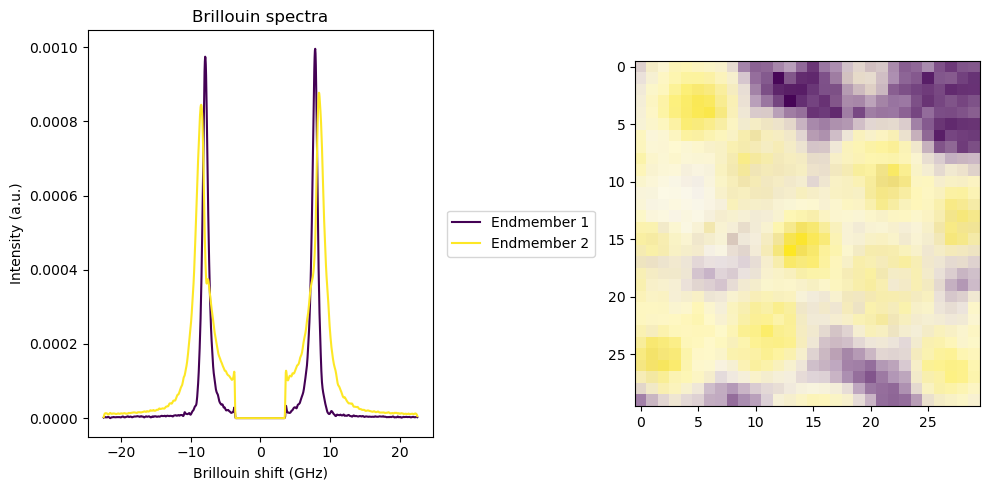

In [5]:
# Here we do a Vertex Component Analysis (VCA)
# Definition of the VCA parameters. Important for you is here the number of endmembers n_endmembers. Abundance_method is less relevant to you and defines the algorithm to determine the maps of the members.
unmixer = bp.analysis.unmix.VCA(n_endmembers=2, abundance_method='ucls')

# Applying the VCA onto our Brillouin object. That is already all that's to it.
abundance_maps, endmembers = unmixer.apply(pp_brillouin_data)

# Plot the endmembers spectra
plt.figure(figsize=(10, 5), layout='tight')
plt.subplot(121)
bp.plot.spectra(endmembers, pp_brillouin_data.spectral_axis, plot_type="single", label=[f"Endmember {i + 1}" for i in range(len(endmembers))], yscale = 'linear')


# Let's also make an overlay plot of where each endmember is most present using matplotlib
ax = plt.subplot(122)
# Define coloring of the plot
cmap = plt.get_cmap()(np.linspace(0, 1, len(abundance_maps)))
white = [1, 1, 1, 0]

for i in range(len(endmembers)):
    ax.imshow(abundance_maps[i], cmap=LinearSegmentedColormap.from_list('', [white, cmap[i]]))
plt.show()